# 10x7E BEMT validation

Compare the bundled 10x7E geometry against the APC static-thrust measurements and the UIUC thrust-coefficient series. The notebook is intentionally self-contained: it uses only `Data/10x7E.pkl`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scienceplots

from FastBEMT import (
    BEMT,
    Environment,
    Propeller,
    Simulation,
    load_propeller_geometry,
)

plt.style.use(["science", "no-latex"])


In [2]:
rpm_values = np.arange(3000.0, 7500.0, 500.0)
environment = Environment()
simulation = Simulation(
    revolutions=1,
    timesteps_per_revolution=100,
    device="cpu",
)
geometry = load_propeller_geometry("Data/10x7E.pkl")
propeller = Propeller(geometry, environment, simulation)

bemt = BEMT(propeller, rpm=rpm_values, v_inf=0.0)
predicted = bemt.performance.reset_index()


c:\Users\PusinoDavide\FastBEMT\.venv\Lib\site-packages\neuralfoil\main.py:171: RuntimeWarning: divide by zero encountered in log
  (np.log(Re) - 12.5) / 3.5,
c:\Users\PusinoDavide\FastBEMT\.venv\Lib\site-packages\aerosandbox\numpy\surrogate_model_tools.py:253: RuntimeWarning: invalid value encountered in divide
  return x / (1 + _np.exp(-beta * x))
c:\Users\PusinoDavide\FastBEMT\.venv\Lib\site-packages\neuralfoil\main.py:227: RuntimeWarning: invalid value encountered in matmul
  x = w @ x + np.reshape(b, (-1, 1))
c:\Users\PusinoDavide\FastBEMT\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\PusinoDavide\FastBEMT\.venv\Lib\site-packages\aerosandbox\library\aerodynamics\viscous.py:142: RuntimeWarning: divide by zero encountered in scalar divide
  return 0.074 / Re_L ** (1 / 5)


In [3]:
measured_thrust = np.array(
    [1.321277, 1.731331, 2.313578, 2.979274, 3.704298, 4.589624, 5.475130, 6.609976, 7.752219]
)
measured_thrust_std = np.array(
    [0.041742, 0.097682, 0.042499, 0.046986, 0.029013, 0.063586, 0.057441, 0.036956, 0.034880]
)
diameter = 2.0 * geometry["tip_radius"]
coefficient_scale = environment.rho * (rpm_values / 60.0) ** 2 * diameter**4
measured_ct = measured_thrust / coefficient_scale
measured_ct_std = measured_thrust_std / coefficient_scale

uiuc_rpm = np.array(
    [1975, 2292, 2632, 2908, 3211, 3504, 3815, 4144, 4409, 4711, 5011, 5325, 5624, 5938, 6231, 6542]
)
uiuc_ct = np.array(
    [0.0981, 0.1001, 0.1015, 0.1021, 0.1033, 0.1038, 0.1043, 0.1051, 0.1050, 0.1062, 0.1071, 0.1077, 0.1118, 0.1126, 0.1133, 0.1139]
)

comparison = pd.DataFrame(
    {
        "rpm": rpm_values,
        "predicted_thrust_coefficient": predicted["thrust_coefficient"],
        "measured_thrust_coefficient": measured_ct,
        "absolute_error": np.abs(predicted["thrust_coefficient"] - measured_ct),
    }
)
comparison


,rpm,predicted_thrust_coefficient,measured_thrust_coefficient,absolute_error
0,3000.0,0.089121,0.103653,0.014532
1,3500.0,0.092776,0.099787,0.007012
2,4000.0,0.098106,0.102093,0.003987
3,4500.0,0.103900,0.103876,0.000024
4,5000.0,0.108227,0.104616,0.003612
5,5500.0,0.110644,0.107123,0.003521
6,6000.0,0.112086,0.107380,0.004706
7,6500.0,0.114003,0.110460,0.003543
8,7000.0,0.114985,0.111702,0.003283


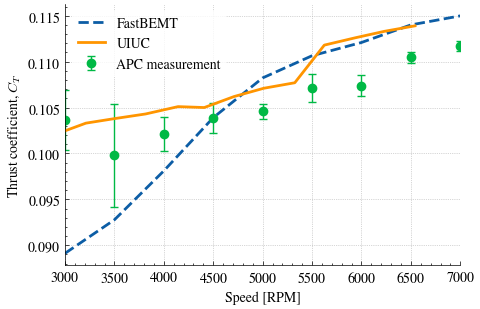

In [4]:
figure, axis = plt.subplots(figsize=(5.0, 3.3))
axis.plot(
    rpm_values,
    predicted["thrust_coefficient"],
    "--",
    linewidth=2,
    label="FastBEMT",
)
axis.errorbar(
    rpm_values,
    measured_ct,
    yerr=measured_ct_std,
    fmt="o",
    capsize=3,
    label="APC measurement",
)
axis.plot(uiuc_rpm, uiuc_ct, linewidth=2, label="UIUC")
axis.set_xlabel("Speed [RPM]")
axis.set_ylabel("Thrust coefficient, $C_T$")
axis.set_xlim(3000, 7000)
axis.grid(True, linestyle=":")
axis.spines[["top", "right"]].set_visible(False)
axis.tick_params(top=False, right=False, which="both")
axis.legend(frameon=True, edgecolor="none")
figure.tight_layout()
plt.show()
